# Lekcja 4 — Podstawy MIMO

## Cel nauki
- **num_tx / num_rx** — anteny nadawcze i odbiorcze
- **Streams** — niezależne strumienie danych
- **MIMO w OFDM** — grid rozszerzony o wymiar anten/streamów

## Równanie (uproszczone)
$$ \mathbf{y} = \mathbf{H} \mathbf{x} + \mathbf{n} $$

gdzie $\mathbf{H}$ to macierz kanału MIMO.

## Co zastąpi sieć?
Przy MIMO klasyczny receiver robi jeszcze **detekcję MIMO** (np. LMMSE).
Sieć może uczyć się separacji strumieni z tensora `[Real, Imag, Antennas, Time, Freq]`.


In [1]:
import sys
from pathlib import Path

# Dodaj src/ do PYTHONPATH
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    import sionna as sn
    import sionna.phy
except ImportError as e:
    raise ImportError(
        "Brak Sionny. Uruchom z katalogu magisterka/: ./scripts/drun sync"
    ) from e

from src.utils.setup import print_environment, get_device

sn.phy.config.seed = 42
device = get_device()
print_environment()


=== Środowisko neural-receiver ===
Sionna:  2.0.1
PyTorch: 2.13.0+cu129
CUDA:    True
Device:  cuda
GPU:     NVIDIA GeForce GTX 1660 SUPER


## Resource grid z wieloma streamami

Grid MIMO shape: torch.Size([4, 1, 2, 14, 64])


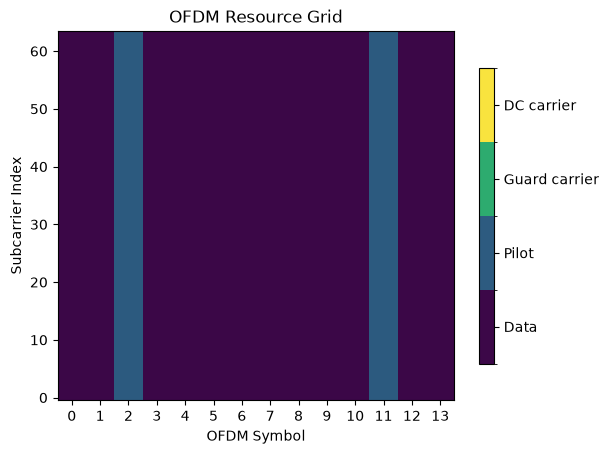

In [2]:
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper

NUM_STREAMS = 2
rg = ResourceGrid(
    num_ofdm_symbols=14,
    fft_size=64,
    subcarrier_spacing=30e3,
    num_tx=1,
    num_streams_per_tx=NUM_STREAMS,
    cyclic_prefix_length=6,
    pilot_pattern="kronecker",
    pilot_ofdm_symbol_indices=[2, 11],
)
rg.show()

rg_mapper = ResourceGridMapper(rg)
NUM_BPS = 2
mapper = sn.phy.mapping.Mapper(
    constellation=sn.phy.mapping.Constellation("qam", NUM_BPS)
)

batch = 4
bits = sn.phy.mapping.BinarySource()(
    [batch, NUM_STREAMS * rg.num_data_symbols * NUM_BPS]
)
# Sionna oczekuje [batch, num_tx, num_streams, num_data_symbols]
sym = mapper(bits).reshape(batch, 1, NUM_STREAMS, rg.num_data_symbols)
x_rg = rg_mapper(sym)
print("Grid MIMO shape:", x_rg.shape)


## Kanał MIMO (Rayleigh block fading)

In [3]:
from sionna.phy.channel import RayleighBlockFading, OFDMChannel

# 1 gNB (2 anteny RX), 1 UE (2 anteny TX / streamy)
rayleigh = RayleighBlockFading(
    num_rx=1,
    num_rx_ant=2,
    num_tx=1,
    num_tx_ant=NUM_STREAMS,
)
mimo_channel = OFDMChannel(
    channel_model=rayleigh,
    resource_grid=rg,
    add_awgn=True,
    normalize_channel=True,
)

no_mimo = sn.phy.utils.ebnodb2no(10.0, NUM_BPS, 1.0)
y_mimo = mimo_channel(x_rg, no_mimo)
print("RX grid shape:", y_mimo.shape)


RX grid shape: torch.Size([4, 1, 2, 14, 64])


## Podsumowanie
MIMO zwiększa wymiarowość tensorów — to ważne przy projektowaniu wejścia CNN.

## Ćwiczenie
Porównaj liczbę pilotów w gridzie dla 1 vs 2 streamów (`rg.num_pilot_symbols`).

**Następna lekcja:** `05_5g_pusch.ipynb`
